# Imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# repo root on path
sys.path.insert(0, str(Path("..").resolve()))
from mvpfn import BarDistribution, PFN
from mvpfn.priors import scm_prior, eval_scm
from mvpfn.extensions.dopfn import DoPFN
from mvpfn.train import _batch_loss

# Configuration

In [2]:
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [3]:
SEQ_LEN = 100
BATCH = 48
NUM_FEATURES = 3 # treatment + 2 covariates
NOISE = 0.05
CONFOUND_SCALE = 5
Y_LOW, Y_HIGH = -6.0 * CONFOUND_SCALE, 6.0 * CONFOUND_SCALE
NUM_BARS = 50
STEPS = 1500
LR = 3e-3

In [4]:
N_CTX, N_QUERY = 20, 20
ATES = [0.25, 0.5, 0.75, 1.0]
n_train_sampler = lambda seq_len: seq_len // 2  # 50% context, 50% queries

# Functions

In [5]:
def _train_step(model, optimizer, criterion, x_ctx, y_ctx, x_q, y_q, grad_clip=1.0):
    """
    Training step for Do-PFN and PFN.

    Args:
        model (torch.nn.Module): The model to train.
        optimizer (torch.optim.Optimizer): The optimizer.
        criterion (torch.nn.Module): Loss defining the task (typically ``BarDistribution``).
        x_ctx (torch.Tensor): Observational context inputs.
        y_ctx (torch.Tensor): Observational context targets.
        x_q (torch.Tensor): Query inputs.
        y_q (torch.Tensor): Query targets.
        grad_clip (float): Max gradient norm for clipping.

    Returns:
        float: The loss value.
    """

    # forward pass
    logits = model(x_ctx, y_ctx, x_q)

    # compute loss
    loss = _batch_loss(criterion, logits, y_q)

    # reset gradients
    optimizer.zero_grad()

    # compute gradients
    loss.backward()

    # clip gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    
    # update parameters
    optimizer.step()

    return loss.item()


def train_do_vs_pfn(model_do, model_pfn, criterion, get_batch, *, steps, lr, n_train_sampler, device, log_every=100):
    """
    Train two models (Do-PFN and PFN) on the same SCM batch per step.

    Args:
        model_do (torch.nn.Module): The Do-PFN model.
        model_pfn (torch.nn.Module): The PFN model.
        criterion (torch.nn.Module): The loss function.
        get_batch (GetDoBatch): Prior sampler returning one batch.
        steps (int): Number of optimisation steps (dataset batches).
        lr (float): Adam learning rate.
        n_train_sampler (Callable[[int], int]): Maps ``seq_len`` to ``n_train``.
        device (str): Device to train on.
        log_every (int): Steps between average-loss logs (``0`` to disable).

    Returns:
        tuple[torch.nn.Module, torch.nn.Module]: The trained models (also trained in place).
    """

    model_do.to(device).train()
    model_pfn.to(device).train()

    opt_do, opt_pfn = torch.optim.Adam(model_do.parameters(), lr=lr), torch.optim.Adam(model_pfn.parameters(), lr=lr)
    
    loss_do, loss_pfn = 0.0, 0.0
    for step in range(1, steps + 1):

        # draw a batch of datasets from the prior and move to device
        x_obs, y_obs, x_int, y_int = get_batch()
        x_obs, y_obs, x_int, y_int = x_obs.to(device), y_obs.to(device), x_int.to(device), y_int.to(device)
        
        n = n_train_sampler(x_obs.shape[0])
        ctx_x, ctx_y = x_obs[:n], y_obs[:n]

        loss_do += _train_step(
            model_do, opt_do, criterion, ctx_x, ctx_y, x_int[n:], 
            y_int[n:] # interventional query 
            )
        
        loss_pfn += _train_step(
            model_pfn, opt_pfn, criterion, ctx_x, ctx_y, x_obs[n:], 
            y_obs[n:] # observational query
        )
        
        if log_every and step % log_every == 0:
            print(f"step {step}/{steps} | Do-PFN {loss_do / log_every:.4f} | PFN {loss_pfn / log_every:.4f}")
            loss_do, loss_pfn = 0.0, 0.0
    
    return model_do.eval(), model_pfn.eval()


@torch.no_grad()
def predict_cate_pfn(model, x_obs, y_obs, x_query, criterion):
    """
    Conditional average treatment effect for observational PFN.

    Args:
        model (torch.nn.Module): The observational PFN model.
        x_obs (torch.Tensor): Observational context inputs of shape ``(n_ctx, batch, num_features)``.
        y_obs (torch.Tensor): Observational context targets of shape ``(n_ctx, batch)``.
        x_query (torch.Tensor): Query inputs of shape ``(n_query, batch, num_features)``
            (treatment column is overwritten).
        criterion (BarDistribution): Output distribution head.

    Returns:
        torch.Tensor: CATE of shape ``(n_query, batch)``.
    """
    
    x1, x0 = x_query.clone(), x_query.clone()
    x1[..., 0], x0[..., 0] = 1.0, 0.0 # treatment

    y1 = criterion.mean(model(x_obs, y_obs, x1))
    y0 = criterion.mean(model(x_obs, y_obs, x0))
    
    return y1 - y0

# Prior

In [6]:
criterion = BarDistribution(torch.linspace(Y_LOW, Y_HIGH, NUM_BARS + 1), full_support=True)
get_do_batch = scm_prior(SEQ_LEN, BATCH, NUM_FEATURES, NOISE, confound_scale=CONFOUND_SCALE)

x_obs, y_obs, x_int, y_int = get_do_batch()
print("x_obs", x_obs.shape, "y_obs", y_obs.shape)

x_obs torch.Size([100, 48, 3]) y_obs torch.Size([100, 48])


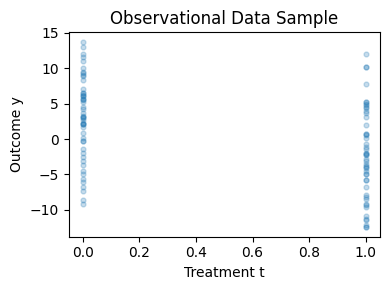

In [7]:
t = x_obs[:, 0, 0].cpu()
y = y_obs[:, 0].cpu()
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(t, y, alpha=0.25, s=12)
ax.set(xlabel="Treatment t", ylabel="Outcome y", title="Observational Data Sample")
plt.tight_layout()
plt.show()

## Training

In [8]:
model_kwargs = dict(
    num_features=NUM_FEATURES,
    n_out=criterion.num_bars,
    d_model=64,
    nhead=4,
    dim_feedforward=128,
    num_layers=3,
)

model_do, model_pfn = train_do_vs_pfn(
    DoPFN(**model_kwargs), PFN(**model_kwargs), # train both models on same SCM batch per step
    criterion, get_do_batch,
    steps=STEPS, lr=LR, n_train_sampler=n_train_sampler, device=device, log_every=100,
)

/Users/noelkronenberg/Documents/GitHub/mv-pfn/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


step 100/1500 | Do-PFN 2.4002 | PFN 2.2521
step 200/1500 | Do-PFN 1.2979 | PFN 1.2459
step 300/1500 | Do-PFN 0.8814 | PFN 0.8805
step 400/1500 | Do-PFN 0.7776 | PFN 0.7338
step 500/1500 | Do-PFN 0.6704 | PFN 0.6317
step 600/1500 | Do-PFN 0.5949 | PFN 0.5706
step 700/1500 | Do-PFN 0.6094 | PFN 0.5654
step 800/1500 | Do-PFN 0.5388 | PFN 0.5523
step 900/1500 | Do-PFN 0.5032 | PFN 0.4966
step 1000/1500 | Do-PFN 0.5080 | PFN 0.4650
step 1100/1500 | Do-PFN 0.4778 | PFN 0.4842
step 1200/1500 | Do-PFN 0.4963 | PFN 0.4545
step 1300/1500 | Do-PFN 0.4636 | PFN 0.4446
step 1400/1500 | Do-PFN 0.4535 | PFN 0.4592
step 1500/1500 | Do-PFN 0.4555 | PFN 0.4439


## Evaluation

ATE=0.25 | True=0.250  Do-PFN=0.283  PFN=0.006  Naive=-4.361
ATE=0.50 | True=0.500  Do-PFN=0.519  PFN=0.262  Naive=-4.111
ATE=0.75 | True=0.750  Do-PFN=0.662  PFN=0.534  Naive=-3.861
ATE=1.00 | True=1.000  Do-PFN=0.789  PFN=0.672  Naive=-3.611


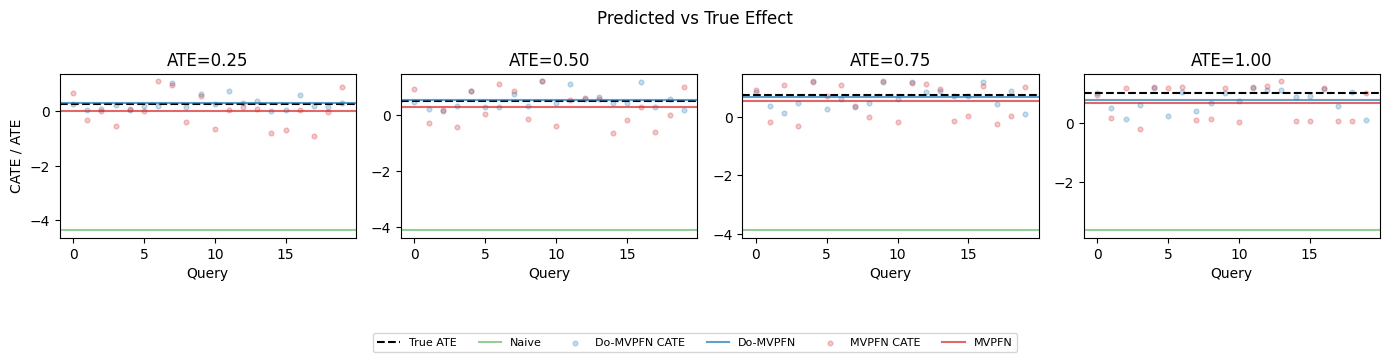

In [9]:
results = []
fig, axes = plt.subplots(1, len(ATES), figsize=(3.5 * len(ATES), 3))
axes = axes if len(ATES) > 1 else [axes]

for i, (ax, ate) in enumerate(zip(axes, ATES)):
    show_lbl = i == 0

    # sample from fixed SCM
    x_ctx, y_ctx, x_query, true_ate = eval_scm(
        N_CTX + N_QUERY,
        num_features=NUM_FEATURES,
        noise=NOISE,
        ate=ate,
        confound_scale=CONFOUND_SCALE,
        seed=0,
    )
    
    x_ctx, y_ctx, x_query = x_ctx.to(device), y_ctx.to(device), x_query.to(device)

    with torch.no_grad():
        
        # PFNs
        cate_do = model_do.predict_cate(x_ctx[:N_CTX], y_ctx[:N_CTX], x_query[N_CTX:], criterion)[:, 0].cpu()
        cate_pfn = predict_cate_pfn(model_pfn, x_ctx[:N_CTX], y_ctx[:N_CTX], x_query[N_CTX:], criterion)[:, 0].cpu()
        ate_do, ate_pfn = cate_do.mean(), cate_pfn.mean()

        # Naive
        t_ctx, y_cpu = x_ctx[:N_CTX, 0, 0].cpu(), y_ctx[:N_CTX, 0].cpu()
        cate_naive = y_cpu[t_ctx == 1].mean() - y_cpu[t_ctx == 0].mean()

    results.append({
        "ate": ate, "true": true_ate,
        "dopfn": ate_do.item(), "pfn": ate_pfn.item(), "naive": cate_naive.item(),
    })
    print(f"ATE={ate:.2f} | True={true_ate:.3f}  Do-PFN={ate_do:.3f}  PFN={ate_pfn:.3f}  Naive={cate_naive:.3f}")

    ax.axhline(true_ate, color="k", ls="--", label="True ATE" if show_lbl else "_nolegend_")
    ax.axhline(cate_naive, color="C2", ls="-", alpha=0.5, label="Naive" if show_lbl else "_nolegend_")
    ax.scatter(range(N_QUERY), cate_do, s=12, alpha=0.25, color="C0", label="Do-MVPFN CATE" if show_lbl else "_nolegend_")
    ax.axhline(ate_do, color="C0", ls="-", alpha=0.7, label="Do-MVPFN" if show_lbl else "_nolegend_")
    ax.scatter(range(N_QUERY), cate_pfn, s=12, alpha=0.25, color="C3", label="MVPFN CATE" if show_lbl else "_nolegend_")
    ax.axhline(ate_pfn, color="C3", ls="-", alpha=0.7, label="MVPFN" if show_lbl else "_nolegend_")
    ax.set(xlabel="Query", title=f"ATE={ate:.2f}")

axes[0].set_ylabel("CATE / ATE")
fig.suptitle("Predicted vs True Effect")
fig.tight_layout()
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
fig.subplots_adjust(bottom=0.22)
plt.show()

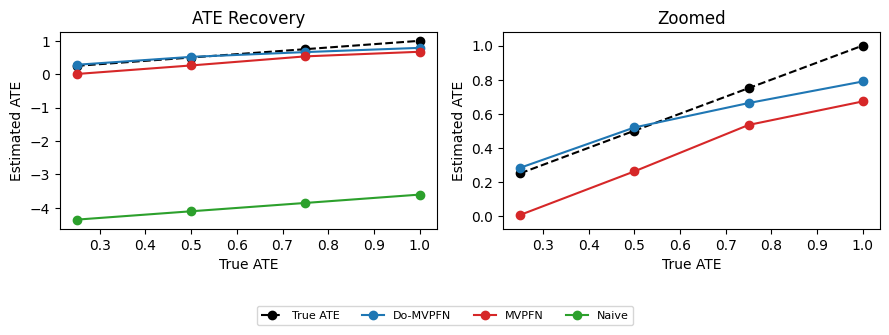

In [11]:
xs = [r["ate"] for r in results]
true = [r["true"] for r in results]
dopfn = [r["dopfn"] for r in results]
pfn = [r["pfn"] for r in results]
naive = [r["naive"] for r in results]

fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(9, 3))
for i, a in enumerate((ax, ax_zoom)):
    lbl = i == 0
    a.plot(xs, true, "k--o", label="True ATE" if lbl else "_nolegend_")
    a.plot(xs, dopfn, "C0-o", label="Do-MVPFN" if lbl else "_nolegend_")
    a.plot(xs, pfn, "C3-o", label="MVPFN" if lbl else "_nolegend_")
    a.plot(xs, naive, "C2-o", label="Naive" if lbl else "_nolegend_")
    a.set(xlabel="True ATE", ylabel="Estimated ATE")

ax.set_title("ATE Recovery")
zoom = true + dopfn + pfn
margin = 0.08
ax_zoom.set_title("Zoomed")
ax_zoom.set_ylim(min(zoom) - margin, max(zoom) + margin)
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8)
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()